In [15]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler





In [16]:
df_model_ready = pd.read_csv('Cleaned_California_Housing.csv', low_memory=False)

def prepare_oot_modeling_data(df, target_col, x_months):
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])
    max_date = df['CloseDate'].max()
    test_start_date = max_date - pd.DateOffset(months=1)
    train_start_date = test_start_date - pd.DateOffset(months=x_months)

    test_mask = (df['CloseDate'] > test_start_date) & (df['CloseDate'] <= max_date)
    train_mask = (df['CloseDate'] > train_start_date) & (df['CloseDate'] <= test_start_date)

    df_train = df[train_mask].copy()
    df_test = df[test_mask].copy()

    y_train = np.log1p(df_train[target_col]) 
    y_test = np.log1p(df_test[target_col])

    X_train = df_train.drop(columns=[target_col, 'CloseDate'])
    X_test = df_test.drop(columns=[target_col, 'CloseDate'])

    num_cols = ['LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 
                'BathroomsTotalInteger', 'YearBuilt', 'AssociationFee', 'GarageSpaces']

    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    return X_train, X_test, y_train, y_test
   

window_options = [3, 6, 9, 12]
datasets_dict = {}
for x in window_options:
    X_train, X_test, y_train, y_test = prepare_oot_modeling_data(df_model_ready, 'ClosePrice', x)
    if X_train is not None:
        datasets_dict[f"{x}_Months"] = {
            'X_train': X_train, 'X_test': X_test, 
            'y_train': y_train, 'y_test': y_test
        }

In [17]:
results = []
for window_name, data in datasets_dict.items():
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']
    
    baseline_model = LinearRegression()
    baseline_model.fit(X_train, y_train)
    y_pred = baseline_model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        'Training_Window': window_name,
        'Train_Size': len(X_train),
        'Test_Size': len(X_test),
        'R2_Score': r2,
        'RMSE_Log': rmse
    })

df_results = pd.DataFrame(results)

In [18]:

df_results_sorted = df_results.sort_values(by='R2_Score', ascending=False)
print(df_results_sorted.to_string(index=False))

best_run = df_results_sorted.iloc[0]
print(f"\n💡 Based on the evaluation results, using 【{best_run['Training_Window']}】 of historical data achieved the best performance in forecasting housing prices for the following month!")
print(f"   Best baseline R² score: {best_run['R2_Score']:.4f}")

Training_Window  Train_Size  Test_Size  R2_Score  RMSE_Log
      12_Months      127566      11804  0.725359  0.358904
       3_Months       31160      11804  0.724669  0.359354
       6_Months       58756      11804  0.724411  0.359523
       9_Months       93051      11804  0.724411  0.359523

💡 Based on the evaluation results, using 【12_Months】 of historical data achieved the best performance in forecasting housing prices for the following month!
   Best baseline R² score: 0.7254


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


best_window = "12_Months"
X_train_best = datasets_dict[best_window]['X_train']
y_train_best = datasets_dict[best_window]['y_train']
X_test_best = datasets_dict[best_window]['X_test']
y_test_best = datasets_dict[best_window]['y_test']

best_model = LinearRegression()
best_model.fit(X_train_best, y_train_best)
best_pred = best_model.predict(X_test_best)


C:\Users\Manzh\AppData\Local\Temp\ipykernel_30724\4105957208.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


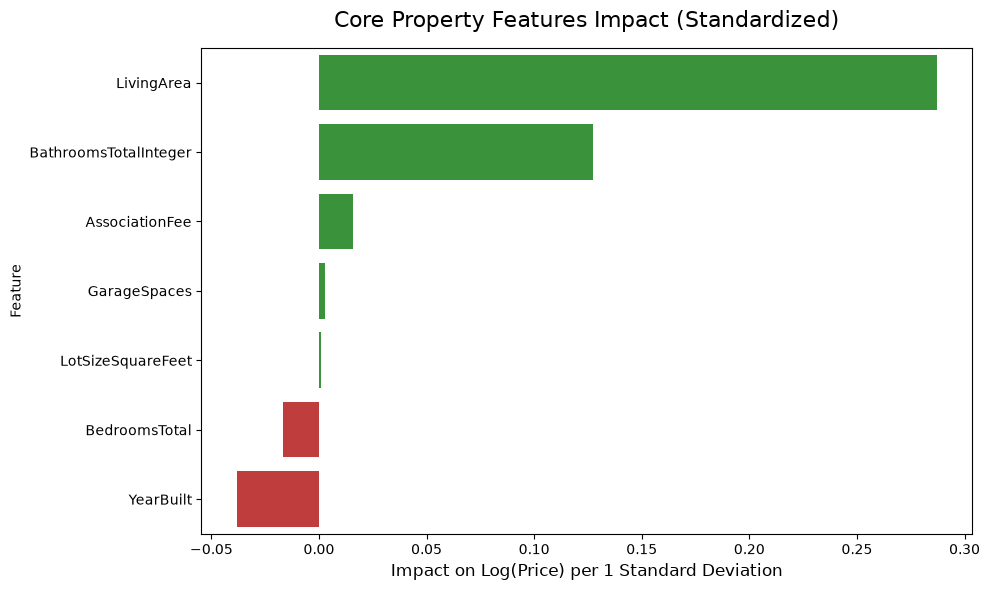

C:\Users\Manzh\AppData\Local\Temp\ipykernel_30724\4105957208.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


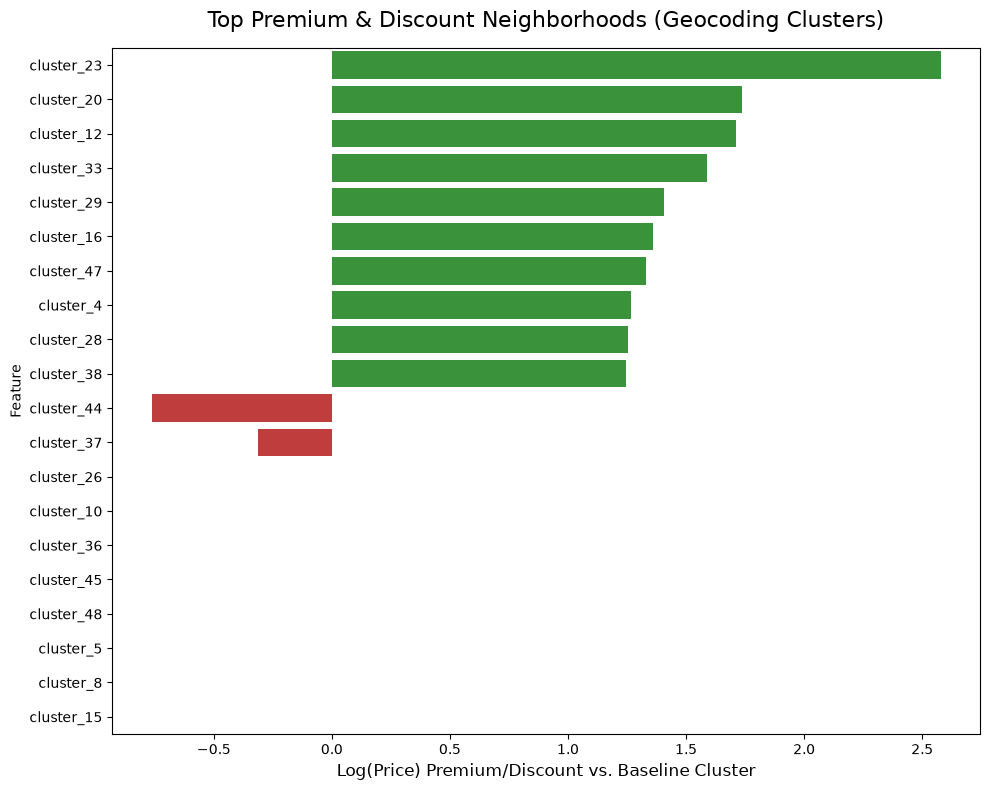

In [20]:
coefficients = pd.DataFrame({
    'Feature': X_train_best.columns,
    'Coefficient': best_model.coef_
})


core_coefs = coefficients[~coefficients['Feature'].str.startswith('cluster_')].copy()
geo_coefs = coefficients[coefficients['Feature'].str.startswith('cluster_')].copy()


plt.figure(figsize=(10, 6))
core_coefs = core_coefs.sort_values(by='Coefficient', ascending=False)
sns.barplot(
    x='Coefficient', y='Feature', data=core_coefs,
    palette=['#2ca02c' if x > 0 else '#d62728' for x in core_coefs['Coefficient']]
)
plt.title('Core Property Features Impact (Standardized)', fontsize=16, pad=15)
plt.xlabel('Impact on Log(Price) per 1 Standard Deviation', fontsize=12)
plt.tight_layout()
plt.show()


top_premium = geo_coefs.sort_values(by='Coefficient', ascending=False).head(10)
top_discount = geo_coefs.sort_values(by='Coefficient', ascending=True).head(10)
geo_extremes = pd.concat([top_premium, top_discount])

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Coefficient', y='Feature', data=geo_extremes,
    palette=['#2ca02c' if x > 0 else '#d62728' for x in geo_extremes['Coefficient']]
)
plt.title('Top Premium & Discount Neighborhoods (Geocoding Clusters)', fontsize=16, pad=15)
plt.xlabel('Log(Price) Premium/Discount vs. Baseline Cluster', fontsize=12)
plt.tight_layout()
plt.show()

insights
1. After controlling for location and other factors, “the larger the house, the higher the selling price.”
2. The weighting for the bathroom is extremely high—far exceeding that of the bedrooms.
3. Although the number of bedrooms is negative, this is based on the assumption that the total living area remains constant. This means that, with the living area unchanged, the fewer bedrooms there are, 4.the more valuable the property is.
4. The older the house, the less it’s worth.
5. The second chart shows that there is a very, very strong correlation between home prices and location in California.

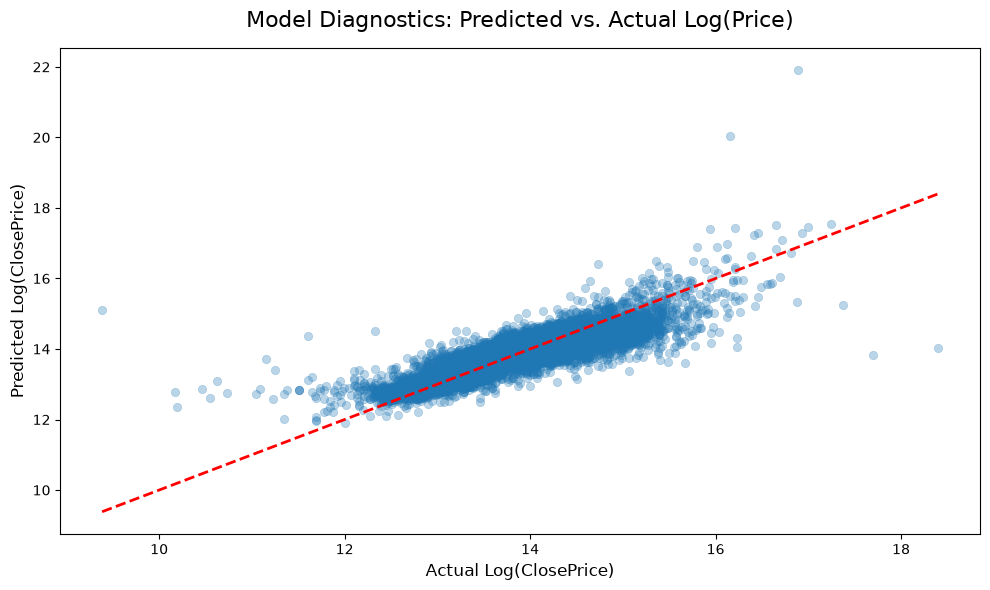

In [14]:
residuals = y_test_best - best_pred

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_best, y=best_pred, alpha=0.3, color='#1f77b4', edgecolor=None)

plt.plot([y_test_best.min(), y_test_best.max()], [y_test_best.min(), y_test_best.max()], 
         color='red', linestyle='--', linewidth=2)

plt.title('Model Diagnostics: Predicted vs. Actual Log(Price)', fontsize=16, pad=15)
plt.xlabel('Actual Log(ClosePrice)', fontsize=12)
plt.ylabel('Predicted Log(ClosePrice)', fontsize=12)
plt.tight_layout()
plt.show()

Linear regression, used as the baseline, has already fulfilled its purpose exceptionally well; it perfectly explains the patterns in housing prices in the mass market. However, it is too rigid to handle the extremes of a polarized market.

This sets the stage perfectly for the next advanced modeling phase of our project: we need to introduce nonlinear algorithms (such as Random Forest or XGBoost tree models).